In [7]:
import pandas as pd

merged_df = pd.read_csv(r"C:\Personal\Capstone\merged_df_copy.csv")

C:\Users\naman\AppData\Local\Temp\ipykernel_24972\2048760861.py:3: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  merged_df = pd.read_csv(r"C:\Personal\Capstone\merged_df_copy.csv")


In [8]:
merged_df["filenames"]

0        ['event0_Flood_IMERG_Precipitation_Rate_2012-1...
1        ['event1_Heavy_Rain_IMERG_Precipitation_Rate_2...
2        ['event2_Heavy_Rain_IMERG_Precipitation_Rate_2...
3        ['event3_Flash_Flood_IMERG_Precipitation_Rate_...
4        ['event4_Flash_Flood_IMERG_Precipitation_Rate_...
                               ...                        
35132                                                  NaN
35133                                                  NaN
35134                                                  NaN
35135                                                  NaN
35136                                                  NaN
Name: filenames, Length: 35137, dtype: object

In [9]:
meteo_cols = [col for col in merged_df.columns if col.startswith("prev_72h")]
meteo_cols.remove("prev_72h_weather")
meteo_cols.remove("prev_72h_weather_code")
meteo_cols.remove("prev_72h_snow_depth")
meteo_cols.remove("prev_72h_snowfall")

In [10]:

import numpy as np
from tqdm import tqdm
import ast
for col in tqdm(meteo_cols):
    merged_df[col] = merged_df[col].apply(lambda x: np.array(ast.literal_eval(x)) if isinstance(x, str) else np.array(x))

100%|██████████| 27/27 [02:01<00:00,  4.49s/it]


In [11]:
metadata = pd.read_csv(r"C:\Personal\Capstone\satellite_images\satellite_images_metadata.csv")

In [12]:
metadata

,event_id,event_type,layer,image_filename,download_time,image_date,days_before_event,bbox,event_date
0,7010,Flash Flood,VIIRS_SNPP_Cirrus_Reflectance_SWIR_M11,event7010_Flash_Flood_VIIRS_SNPP_Cirrus_Reflec...,2025-04-01,2018-10-12,0,"[34.54, -80.42, 40.54, -74.42]",2018-10-12
1,7010,Flash Flood,VIIRS_SNPP_Cirrus_Reflectance_VIS_NIR,event7010_Flash_Flood_VIIRS_SNPP_Cirrus_Reflec...,2025-04-01,2018-10-12,0,"[34.54, -80.42, 40.54, -74.42]",2018-10-12
2,7010,Flash Flood,MODIS_Terra_CorrectedReflectance_TrueColor,event7010_Flash_Flood_MODIS_Terra_CorrectedRef...,2025-04-01,2018-10-12,0,"[34.54, -80.42, 40.54, -74.42]",2018-10-12
3,7010,Flash Flood,VIIRS_SNPP_Cirrus_Reflectance_SWIR_M11,event7010_Flash_Flood_VIIRS_SNPP_Cirrus_Reflec...,2025-04-01,2018-10-11,1,"[34.54, -80.42, 40.54, -74.42]",2018-10-12
4,7010,Flash Flood,VIIRS_SNPP_Cirrus_Reflectance_VIS_NIR,event7010_Flash_Flood_VIIRS_SNPP_Cirrus_Reflec...,2025-04-01,2018-10-11,1,"[34.54, -80.42, 40.54, -74.42]",2018-10-12
...,...,...,...,...,...,...,...,...,...
253148,35135,Flood,VIIRS_SNPP_Cirrus_Reflectance_VIS_NIR,event35135_Flood_VIIRS_SNPP_Cirrus_Reflectance...,2025-04-02,2012-04-26,1,"[40.86, -119.56, 46.92, -113.44]",2012-04-27
253149,35135,Flood,MODIS_Terra_CorrectedReflectance_TrueColor,event35135_Flood_MODIS_Terra_CorrectedReflecta...,2025-04-02,2012-04-26,1,"[40.86, -119.56, 46.92, -113.44]",2012-04-27
253150,35135,Flood,VIIRS_SNPP_Cirrus_Reflectance_SWIR_M11,event35135_Flood_VIIRS_SNPP_Cirrus_Reflectance...,2025-04-02,2012-04-25,2,"[40.86, -119.56, 46.92, -113.44]",2012-04-27
253151,35135,Flood,VIIRS_SNPP_Cirrus_Reflectance_VIS_NIR,event35135_Flood_VIIRS_SNPP_Cirrus_Reflectance...,2025-04-02,2012-04-25,2,"[40.86, -119.56, 46.92, -113.44]",2012-04-27


In [13]:
filenames = []

# Ensure the DataFrame has enough rows
if len(merged_df) > 7000:
    for i in range(7000, len(merged_df)):
        temp = []
        event_id = merged_df["event_id"].iloc[i]
        
        # Check if event_id exists in metadata
        if event_id in metadata["event_id"].values:
            for j in metadata[metadata["event_id"] == event_id]["image_filename"].values:

                temp.append(j)
        else:
            print(f"event_id {event_id} not found in metadata")
        

        filenames.append(temp)
else:
    print("merged_df has fewer than 7000 rows")

event_id 29465 not found in metadata
event_id 29671 not found in metadata
event_id 31306 not found in metadata
event_id 32075 not found in metadata
event_id 32171 not found in metadata
event_id 32625 not found in metadata
event_id 34020 not found in metadata
event_id 35054 not found in metadata


In [14]:
merged_df["filenames"]

0        ['event0_Flood_IMERG_Precipitation_Rate_2012-1...
1        ['event1_Heavy_Rain_IMERG_Precipitation_Rate_2...
2        ['event2_Heavy_Rain_IMERG_Precipitation_Rate_2...
3        ['event3_Flash_Flood_IMERG_Precipitation_Rate_...
4        ['event4_Flash_Flood_IMERG_Precipitation_Rate_...
                               ...                        
35132                                                  NaN
35133                                                  NaN
35134                                                  NaN
35135                                                  NaN
35136                                                  NaN
Name: filenames, Length: 35137, dtype: object

In [15]:
merged_df["filenames"].iloc[7000:] = filenames

C:\Users\naman\AppData\Local\Temp\ipykernel_24972\2317691987.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_df["filenames"].iloc[7000:] = filenames


In [16]:
merged_df["filenames"].iloc[:7000] = merged_df["filenames"].iloc[:7000].apply(ast.literal_eval)

C:\Users\naman\AppData\Local\Temp\ipykernel_24972\456318677.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_df["filenames"].iloc[:7000] = merged_df["filenames"].iloc[:7000].apply(ast.literal_eval)


In [17]:
merged_df["filenames"] =  merged_df["filenames"].apply(lambda x: [f for f in x if "MODIS_Terra_CorrectedReflectance_TrueColor" in f])

In [18]:
temp

['event35136_Flood_VIIRS_SNPP_Cirrus_Reflectance_SWIR_M11_2012-04-28.png',
 'event35136_Flood_VIIRS_SNPP_Cirrus_Reflectance_VIS_NIR_2012-04-28.png',
 'event35136_Flood_MODIS_Terra_CorrectedReflectance_TrueColor_2012-04-28.png',
 'event35136_Flood_VIIRS_SNPP_Cirrus_Reflectance_SWIR_M11_2012-04-27.png',
 'event35136_Flood_VIIRS_SNPP_Cirrus_Reflectance_VIS_NIR_2012-04-27.png',
 'event35136_Flood_MODIS_Terra_CorrectedReflectance_TrueColor_2012-04-27.png',
 'event35136_Flood_VIIRS_SNPP_Cirrus_Reflectance_SWIR_M11_2012-04-26.png',
 'event35136_Flood_VIIRS_SNPP_Cirrus_Reflectance_VIS_NIR_2012-04-26.png',
 'event35136_Flood_MODIS_Terra_CorrectedReflectance_TrueColor_2012-04-26.png']

In [19]:
merged_df["filenames"].isna().sum()

np.int64(0)

In [20]:
import ast
import tensorflow as tf
import pandas as pd


# Base directory where your images are stored
base_image_path = [r"C:\Personal\Capstone\satellite_images\\", r"C:\Personal\Capstone project\Capstone project\satellite_images\satellite_images\\"]

# Function to convert the string representation to a Python list of filenames.
def parse_filenames(filenames_str):
    # Safely evaluate the string to get the list.
    return filenames_str

# Function to load and preprocess a single image.
def load_and_preprocess_image(filename, folder_paths, image_size=(64, 64)):
    # Read the image from disk.
    for path in folder_paths:
        try:
            final_path = path + filename
            image = tf.io.read_file(final_path)
            # Decode PNG (or use tf.image.decode_jpeg for jpg).
            image = tf.image.decode_png(image, channels=3)
            # Convert image to floats in range [0, 1].
            image = tf.image.convert_image_dtype(image, tf.float32)
            # Resize the image to the desired dimensions.
            image = tf.image.resize(image, image_size)
            return image
        except Exception as e:
            continue
    # Function to load all images from the list of filenames and stack them.
def load_images_from_list(filenames_str, base_path=base_image_path, image_size=(64, 64)):
    # Convert string list into actual list of filenames.
    filenames = parse_filenames(filenames_str)
    # Construct full paths and load each image.
    images = []
    for fname in filenames:
    
        img = load_and_preprocess_image(fname, base_path, image_size)
        images.append(img)
    # Stack into a single tensor with shape (num_images, height, width, channels)
    images_tensor = tf.stack(images)
    return images_tensor

# Test the image loading function on the first row.
example_filenames_str = merged_df["filenames"].iloc[0]
images_tensor = load_images_from_list(example_filenames_str)
print("Shape of loaded images tensor:", images_tensor.shape)



Shape of loaded images tensor: (3, 64, 64, 3)


In [3]:
merged_df_new

In [21]:
from tqdm import tqdm
tqdm.pandas()
extreme = merged_df[merged_df["extreme"] == 1]
non_extreme = merged_df[merged_df["extreme"] == 0].sample(n=extreme.shape[0], random_state=42)
merged_df_new = pd.concat([extreme, non_extreme], axis=0, ignore_index=True)
merged_df_new["images_loaded"] = merged_df_new["filenames"].progress_apply(load_images_from_list)

100%|██████████| 6918/6918 [02:59<00:00, 38.46it/s]


In [22]:
merged_df["filenames"] = merged_df["filenames"].apply(lambda x: [f for f in x if "MODIS_Terra_CorrectedReflectance_TrueColor" in f])

In [23]:
merged_df_new["images_loaded"].iloc[0].shape

TensorShape([3, 64, 64, 3])

In [73]:
merged_df_new.to_pickle('merged_df_new.pkl')

In [24]:
%store merged_df_new


Stored 'merged_df_new' (DataFrame)


C:\Users\naman\AppData\Roaming\Python\Python310\site-packages\IPython\extensions\storemagic.py:229: UserWarning: This is now an optional IPython functionality, setting autorestore/merged_df_new requires you to install the `pickleshare` library.
  db[ 'autorestore/' + arg ] = obj


In [4]:
%store -r merged_df_new

C:\Users\naman\AppData\Roaming\Python\Python310\site-packages\IPython\extensions\storemagic.py:148: UserWarning: This is now an optional IPython functionality, using autorestore/merged_df_new requires you to install the `pickleshare` library.
  obj = db["autorestore/" + arg]


In [74]:
loaded_df = pd.read_pickle('merged_df_new.pkl')

In [77]:
loaded_df["images_loaded"].iloc[0].shape

TensorShape([3, 64, 64, 3])

In [85]:
merged_df_new["begin_date_time"]

0       2014-09-27 16:00:00
1       2014-09-21 12:30:00
2       2014-09-27 09:30:00
3       2014-09-09 17:40:00
4       2014-09-09 18:47:00
               ...         
6913    2012-12-02 11:00:00
6914    2014-04-30 11:28:00
6915    2019-07-22 16:04:00
6916    2019-03-13 13:00:00
6917    2017-05-28 20:19:00
Name: begin_date_time, Length: 6918, dtype: object

In [38]:
# Basic data manipulation libraries
import numpy as np
import pandas as pd
import ast
import math
from tqdm import tqdm

# Scikit-learn utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.datasets import make_classification
from collections import Counter

# Imbalanced learning tools
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

# TensorFlow and Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Input, Conv1D, Conv2D, BatchNormalization, 
    MaxPooling1D, MaxPooling2D, Dropout, Add,
    LSTM, Bidirectional, Attention, TimeDistributed,
    LeakyReLU, Activation, Dense,
    GlobalAveragePooling1D, GlobalAveragePooling2D,
    concatenate
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.metrics import Precision, Recall, AUC
def model_build():
        # ---------------------------
    # Weather Data Branch (Simplified)
    # ---------------------------
    weather_input = Input(shape=(72, 27), name='weather_input')

    # Single Conv Block with moderate complexity
    w = Conv1D(filters=64, kernel_size=5, padding='same')(weather_input)
    w = BatchNormalization()(w)
    w = LeakyReLU(alpha=0.01)(w)
    w = MaxPooling1D(pool_size=2)(w)
    w = Dropout(0.3)(w)

    # Single Bidirectional LSTM layer with attention
    w = Bidirectional(LSTM(64, return_sequences=True))(w)
    w = Dropout(0.3)(w)
    weather_features = GlobalAveragePooling1D()(w)

    # ---------------------------
    # Image Data Branch (Simplified)
    # ---------------------------
    image_input = Input(shape=(3, 64, 64, 3), name='image_input')

    # Simplified CNN with fewer layers
    i = TimeDistributed(Conv2D(32, kernel_size=(3, 3), padding='same'))(image_input)
    i = TimeDistributed(BatchNormalization())(i)
    i = TimeDistributed(LeakyReLU(alpha=0.01))(i)
    i = TimeDistributed(MaxPooling2D(pool_size=(2, 2)))(i)
    i = TimeDistributed(Dropout(0.3))(i)

    i = TimeDistributed(Conv2D(64, kernel_size=(3, 3), padding='same'))(i)
    i = TimeDistributed(BatchNormalization())(i)
    i = TimeDistributed(LeakyReLU(alpha=0.01))(i)
    i = TimeDistributed(MaxPooling2D(pool_size=(2, 2)))(i)
    i = TimeDistributed(Dropout(0.3))(i)

    # Global pooling to reduce each image to a feature vector
    i = TimeDistributed(GlobalAveragePooling2D())(i)

    # Single LSTM instead of two
    i = Bidirectional(LSTM(64, return_sequences=False))(i)
    i = Dropout(0.3)(i)
    img_features = Dense(64)(i)
    i = BatchNormalization()(img_features)

    # ---------------------------
    # Merge Branches and Classification Head (Simplified)
    # ---------------------------
    combined_features = concatenate([weather_features, img_features])

    # Simple classification head
    x = Dense(32)(combined_features)
    x = BatchNormalization()(x)
    x = LeakyReLU(alpha=0.01)(x)
    x = Dropout(0.4)(x)
    extreme_output = Dense(1, activation='sigmoid', name='extreme')(x)

    # Define and compile the model
    model = Model(inputs=[weather_input, image_input], outputs=extreme_output)
    optimizer = Adam(learning_rate=1e-4)
    model.compile(optimizer=optimizer,
                loss='binary_crossentropy',
                metrics=['accuracy', Precision(), Recall(), AUC(name='roc_auc')])
    return model

In [78]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv1D, MaxPooling1D, Dropout,
                                     LSTM, Dense, Input)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.metrics import Precision, Recall, AUC
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential, Model # Import Model for Functional API
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, BatchNormalization, Activation,
    LSTM, Bidirectional, Dropout, Dense, LeakyReLU
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
# Import relevant metrics for classification, especially if data is imbalanced
from tensorflow.keras.metrics import Precision, Recall, AUC
# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# --- Data Preparation ---
# Assume merged_df and meteo_cols are defined earlier in your code.
# For multi-class, we now use the "event_type" column.

# Encode the categorical labels to integer values
le = LabelEncoder()
y_encoded = le.fit_transform(merged_df_new["event_type"].values)
# Number of classes (should be 10 based on provided counts)
num_classes = len(le.classes_)

# Convert integer labels to one-hot encoded format
y = tf.keras.utils.to_categorical(y_encoded, num_classes=num_classes)
y_bin = merged_df_new["extreme"].values # Binary labels for extreme events
# Prepare features (assuming meteo_cols contains your meteorological data)
# Here we simulate stacking the data; adjust if your actual data preprocessing is different.


# Split the data into training and testing sets
X_train, X_test, y_train, y_test, y_train_bin, y_test_bin = train_test_split(
    merged_df_new, y,y_bin, test_size=0.2, random_state=42, stratify=y_bin
)


X_train, X_validation, y_train_bin, y_validation_bin = train_test_split(
    X_train,y_train_bin, test_size=0.2, random_state=42, stratify=y_train_bin
)
from collections import Counter
from sklearn.datasets import make_classification
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
# Apply the oversampling to the dataset
X_images = X_train["images_loaded"].values
X_test_images = X_test["images_loaded"].values
X_validation_images = X_validation["images_loaded"].values


X_train = np.stack(X_train[meteo_cols].values.tolist(), axis=0)
X_test = np.stack(X_test[meteo_cols].values.tolist(), axis=0)
X_validation = np.stack(X_validation[meteo_cols].values.tolist(), axis=0)
# Initialize the RandomOverSampler

print("peecentage of positice instance in training data: ", sum(y_train_bin)/len(y_train_bin))
print("percentage of positice instance in test data: ", sum(y_test_bin)/len(y_test_bin))
print("percentage of positice instance in validation data: ", sum(y_validation_bin)/len(y_validation_bin))

print("y resampled shape:", y_train_bin.shape)
# Display class distribution after oversampling
print("Class distribution after oversampling:", Counter(y_train_bin))
# Scale the y_train_bin
scaler = StandardScaler()

# Reshape for scaling: combine timesteps and features
X_train = X_train.reshape(-1, X_train.shape[-1])
X_test = X_test.reshape(-1, X_test.shape[-1])
X_validation = X_validation.reshape(-1, X_validation.shape[-1])
# Fit and transform
print("X resampled shape before scaling:", X_train.shape)
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_validation = scaler.transform(X_validation)
# Reshape back to original structure: (samples, num_features, num_timesteps)
# Note: Here we assume the original shape was (samples, num_features, num_timesteps).
# Adjust reshaping if your data dimensions differ.
X_train = X_train.reshape(-1, 27, 72)
X_test = X_test.reshape(-1, 27, 72)
X_validation = X_validation.reshape(-1, 27, 72)
# Print shapes to verify correctness (should print something like (samples, 27, 72) and (samples, num_classes))
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train_bin.shape)

# --- Reshape Input for Model ---
# Rearranging shape to (samples, timesteps, features), here timesteps=72 and features=27.
X_train = X_train.transpose(0, 2, 1)
X_test  = X_test.transpose(0, 2, 1)
X_validation = X_validation.transpose(0, 2, 1)
num_timesteps = X_train.shape[1]  # should be 72
num_features  = X_train.shape[2]  # should be 27
input_layer = Input(shape=(num_timesteps, num_features))
# --- CNN Feature Extraction Block ---
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, LeakyReLU, MaxPooling1D, Dropout, Add, Dense, Bidirectional, LSTM, GlobalAveragePooling1D, Attention
from tensorflow.keras.optimizers import Adam






import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, LeakyReLU, MaxPooling1D, Dropout, Add, Bidirectional, LSTM, Attention, GlobalAveragePooling1D, Dense, concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

import tensorflow as tf
from tensorflow.keras.layers import (Input, Conv1D, Conv2D, BatchNormalization, LeakyReLU, 
                                     MaxPooling1D, MaxPooling2D, Dropout, Add, Bidirectional, 
                                     LSTM, Attention, GlobalAveragePooling1D, GlobalAveragePooling2D, 
                                     Dense, concatenate)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# # ---------------------------
# # Weather Data Branch
# # ---------------------------
# # For example, assume weather data is a sequence of 100 timesteps with 64 features.
weather_input = Input(shape=(72, 27), name='weather_input')

# Conv Block 1
w = Conv1D(filters=64, kernel_size=3, padding='same')(weather_input)
w = BatchNormalization()(w)
w = LeakyReLU(alpha=0.01)(w)
w = MaxPooling1D(pool_size=2)(w)
w = Dropout(0.3)(w)

# Conv Block 2
w = Conv1D(filters=128, kernel_size=5, padding='same')(w)
w = BatchNormalization()(w)
w = LeakyReLU(alpha=0.01)(w)
w = Dropout(0.3)(w)

# Residual Connection from Block 1
shortcut = Conv1D(filters=128, kernel_size=1, padding='same')(weather_input[:, :weather_input.shape[1]//2, :])
shortcut = BatchNormalization()(shortcut)
w = Add()([w, shortcut])

# Conv Block 3
w = Conv1D(filters=128, kernel_size=7, padding='same')(w)
w = BatchNormalization()(w)
w = LeakyReLU(alpha=0.01)(w)
w = Dropout(0.3)(w)

# LSTM and Attention
w = Bidirectional(LSTM(128, return_sequences=True))(w)
w = Dropout(0.4)(w)
w = Bidirectional(LSTM(64, return_sequences=True))(w)
w = Dropout(0.4)(w)
w = Attention()([w, w])
weather_features = GlobalAveragePooling1D()(w)

# ---------------------------
# Image Data Branch (Feature Extraction for Time-Series of Images)
# ---------------------------
# For example, assume each row contains a sequence of 24 images of shape (224, 224, 3)
image_input = Input(shape=(3, 64, 64, 3), name='image_input')  # Input for the sequence of images

# TimeDistributed wrapper to apply CNN to each image in the sequence
from tensorflow.keras.layers import TimeDistributed

# Apply CNN feature extraction to each image in the sequence
i = TimeDistributed(Conv2D(32, kernel_size=(3, 3), padding='same'))(image_input)
i = TimeDistributed(BatchNormalization())(i)
i = TimeDistributed(LeakyReLU(alpha=0.01))(i)
i = TimeDistributed(MaxPooling2D(pool_size=(2, 2)))(i)
i = TimeDistributed(Dropout(0.3))(i)

i = TimeDistributed(Conv2D(64, kernel_size=(3, 3), padding='same'))(i)
i = TimeDistributed(BatchNormalization())(i)
i = TimeDistributed(LeakyReLU(alpha=0.01))(i)
i = TimeDistributed(MaxPooling2D(pool_size=(2, 2)))(i)
i = TimeDistributed(Dropout(0.3))(i)

i = TimeDistributed(Conv2D(128, kernel_size=(3, 3), padding='same'))(i)
i = TimeDistributed(BatchNormalization())(i)
i = TimeDistributed(LeakyReLU(alpha=0.01))(i)
i = TimeDistributed(MaxPooling2D(pool_size=(2, 2)))(i)
i = TimeDistributed(Dropout(0.3))(i)

# Global pooling to reduce each image to a feature vector
i = TimeDistributed(GlobalAveragePooling2D())(i)

# Process the sequence of feature vectors with an LSTM
i = Bidirectional(LSTM(128, return_sequences=True))(i)
i = Dropout(0.4)(i)
i = Bidirectional(LSTM(64, return_sequences=False))(i)  # Final output for the sequence
i = Dropout(0.4)(i)

# Optional fully connected layer to further process image sequence features
img_features = Dense(128, activation='relu')(i)
img_features = BatchNormalization()(img_features)
img_features = Dropout(0.4)(img_features)

# ---------------------------
# Merge Branches and Build Final Classification Head
# ---------------------------
# Merge the weather and image features
combined_features = concatenate([weather_features, img_features], name='combined_features')

# Fully connected layers for extreme event classification
x = Dense(64)(combined_features)
x = BatchNormalization()(x)
x = LeakyReLU(alpha=0.01)(x)
x = Dropout(0.5)(x)
extreme_output = Dense(1, activation='sigmoid', name='extreme')(x)

# Define the complete multi-modal model
model = Model(inputs=[weather_input, image_input], outputs=extreme_output)

# Compile the model with Adam optimizer and binary cross-entropy loss
optimizer = Adam(learning_rate=1e-4, clipnorm=1.0)
model.compile(optimizer=optimizer,
              loss='binary_crossentropy',
              metrics=[tf.keras.metrics.Accuracy(name='accuracy'),
                       tf.keras.metrics.Precision(),
                       tf.keras.metrics.Recall(),
                       tf.keras.metrics.AUC(name='roc_auc'),
                       tf.keras.metrics.AUC(curve='PR', name='pr_auc')])
# model = model_build()
# Display the model summary
model.summary()


# --- Callbacks ---
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)


# --- Train the Model ---
epochs = 50
batch_size = 32






peecentage of positice instance in training data:  0.5001129433024621
percentage of positice instance in test data:  0.5
percentage of positice instance in validation data:  0.4995483288166215
y resampled shape: (4427,)
Class distribution after oversampling: Counter({np.int64(1): 2214, np.int64(0): 2213})
X resampled shape before scaling: (119529, 72)
X_train shape: (4427, 27, 72)
y_train shape: (4427,)


c:\Users\naman\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 3, 64, 64, │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_33 │ (None, 3, 64, 64, │        896 │ image_input[0][0] │
│ (TimeDistributed)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_34 │ (None, 3, 64, 64, │        128 │ time_distributed… │
│ (TimeDistributed)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ weather_input       │ (None, 72, 27)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_35 │ (None, 3, 64, 64, │          0 │ time_distributed… │
│ (TimeDistributed)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 72, 64)    │      5,248 │ weather_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_36 │ (None, 3, 32, 32, │          0 │ time_distributed… │
│ (TimeDistributed)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 72, 64)    │        256 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_37 │ (None, 3, 32, 32, │          0 │ time_distributed… │
│ (TimeDistributed)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_12      │ (None, 72, 64)    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_38 │ (None, 3, 32, 32, │     18,496 │ time_distributed… │
│ (TimeDistributed)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_3     │ (None, 36, 64)    │          0 │ leaky_re_lu_12[0… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_39 │ (None, 3, 32, 32, │        256 │ time_distributed… │
│ (TimeDistributed)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_18          │ (None, 36, 64)    │          0 │ max_pooling1d_3[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_40 │ (None, 3, 32, 32, │          0 │ time_distributed… │
│ (TimeDistributed)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 36, 128)   │     41,088 │ dropout_18[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_41 │ (None, 3, 16, 16, │          0 │ time_distributed… │
│ (TimeDistributed)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,149,505 (4.39 MB)

 Trainable params: 1,147,777 (4.38 MB)

 Non-trainable params: 1,728 (6.75 KB)

In [46]:
%pip install pytables

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement pytables (from versions: none)
ERROR: No matching distribution found for pytables


In [48]:
merged_df_new.to_pickle('merged_df_new.pkl')

OSError: [Errno 28] No space left on device

In [79]:
import tensorflow as tf
import numpy as np

# Assuming these variables are already defined from your preprocessing:
# X_train        : numpy array of weather data, shape (num_samples, 72, 27) [or (num_samples, timesteps, features)]
# X_validation   : same for validation weather data
# y_train_bin    : binary labels for training, shape (num_samples,)
# y_validation_bin: binary labels for validation
# X_images       : a list or 1D numpy array of image tensors (each of shape (3, 224, 224, 3)) for the training set
# X_validation_images: same for validation set
def is_valid_batch(weather, images, labels):
    # Check shapes of weather data
    weather_shape = tf.shape(weather)
    valid_weather = tf.reduce_all(tf.equal(weather_shape[1:], [72, 27]))

    # Check shapes of image data
    images_shape = tf.shape(images)
    valid_images = tf.reduce_all(tf.equal(images_shape[1:], [3, 64, 64, 3]))

    # Check shapes of labels
    labels_shape = tf.shape(labels)
    valid_labels = tf.equal(tf.rank(labels), 1)  # Assuming labels are 1D

    return tf.logical_and(tf.logical_and(valid_weather, valid_images), valid_labels)

batch_size = 16

def image_generator_fn(images_list):
    for img in images_list:

        if img.shape == (3, 64, 64, 3):
            yield img
        else:
            print("jhe")
            continue  # Skip images with incorrect shape


# Use tf.data.Dataset.from_generator for training images.
ds_images_train = tf.data.Dataset.from_generator(
    lambda: image_generator_fn(X_images),
    output_types=tf.float32,
    output_shapes=(3, 64, 64, 3)
)

ds_images_val = tf.data.Dataset.from_generator(
    lambda: image_generator_fn(X_validation_images),
    output_types=tf.float32,
    output_shapes=(3, 64, 64, 3)
)

ds_images_test = tf.data.Dataset.from_generator(
    lambda: image_generator_fn(X_test_images),
    output_types=tf.float32,
    output_shapes=(3, 64, 64, 3)
)

# Create a dataset for the weather input
ds_weather_train = tf.data.Dataset.from_tensor_slices(X_train)  # shape: (num_samples, 72, 27)
ds_weather_val   = tf.data.Dataset.from_tensor_slices(X_validation)
df_weather_test = tf.data.Dataset.from_tensor_slices(X_test)

# Create a dataset for the labels
ds_labels_train = tf.data.Dataset.from_tensor_slices(y_train_bin)
ds_labels_val   = tf.data.Dataset.from_tensor_slices(y_validation_bin)
ds_labels_test  = tf.data.Dataset.from_tensor_slices(y_test_bin)

# Zip the weather data, image data, and labels together.
# The model expects inputs as a tuple: ([weather_input, image_input], label)
ds_train = tf.data.Dataset.zip(((ds_weather_train, ds_images_train), ds_labels_train))
ds_train = ds_train.batch(batch_size)

# Apply the filter
ds_train = ds_train.filter(lambda inputs, labels: is_valid_batch(inputs[0], inputs[1], labels))

# Prefetch for performance
ds_train = ds_train.prefetch(tf.data.AUTOTUNE)
ds_val   = tf.data.Dataset.zip(((ds_weather_val, ds_images_val), ds_labels_val))
ds_val = ds_val.batch(batch_size)

# Apply the filter
ds_val = ds_val.filter(lambda inputs, labels: is_valid_batch(inputs[0], inputs[1], labels))

# Prefetch for performance
ds_val = ds_val.prefetch(tf.data.AUTOTUNE)
ds_test = tf.data.Dataset.zip(((df_weather_test, ds_images_test), ds_labels_test))
# Batch and prefetch for performance

ds_test = ds_test.batch(batch_size)

# Apply the filter
ds_test = ds_test.filter(lambda inputs, labels: is_valid_batch(inputs[0], inputs[1], labels))

# Prefetch for performance
ds_test = ds_test.prefetch(tf.data.AUTOTUNE)


In [80]:
import math

num_samples = len(X_train)  # Replace with the actual number of training samples
batch_size = 16  # Replace with your batch size

steps_per_epoch = math.ceil(num_samples / batch_size)

In [81]:
steps_per_epoch

277

In [82]:
# Now, train your model using the datasets:
history_1 = model.fit(
    ds_train,
    epochs=50,
    steps_per_epoch=steps_per_epoch,
    validation_data=ds_val,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/50
 17/277 ━━━━━━━━━━━━━━━━━━━━ 3:17 760ms/step - accuracy: 0.0000e+00 - loss: 0.9731 - pr_auc: 0.4442 - precision_3: 0.4476 - recall_3: 0.4175 - roc_auc: 0.4092jhe
105/277 ━━━━━━━━━━━━━━━━━━━━ 1:55 670ms/step - accuracy: 0.0000e+00 - loss: 0.9049 - pr_auc: 0.4845 - precision_3: 0.4716 - recall_3: 0.4346 - roc_auc: 0.4689

KeyboardInterrupt: 

In [35]:
X_images.shape, X_test_images.shape, X_validation_images.shape

((4427,), (1384,), (1107,))

In [ ]:
X_images.reshape(-1, 3, 224, 224, 3).shape

ValueError: cannot reshape array of size 4427 into shape (3,224,224,3)

In [47]:
import tensorflow as tf

# Convert each image tensor to float16
X_images_float16 = [tf.cast(img, tf.float16) for img in X_images]

# Attempt stacking
try:
    X_images_stacked = tf.stack(X_images_float16, axis=0)
    print("Stacked X_images shape:", X_images_stacked.shape)
except Exception as e:
    print("Stacking failed:", e)


Stacking failed: {{function_node __wrapped__Pack_N_4427_device_/job:localhost/replica:0/task:0/device:CPU:0}} OOM when allocating tensor with shape[4427,3,224,224,3] and type half on /job:localhost/replica:0/task:0/device:CPU:0 by allocator mklcpu [Op:Pack] name: stack


In [48]:
del X_images_float16

In [49]:
del X_images_stacked

NameError: name 'X_images_stacked' is not defined

87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step
Test Accuracy: 0.5903
Test Precision: 0.5800
Test Recall: 0.6546
Test F1-Score: 0.6151
Test ROC AUC: 0.6359


c:\Users\naman\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


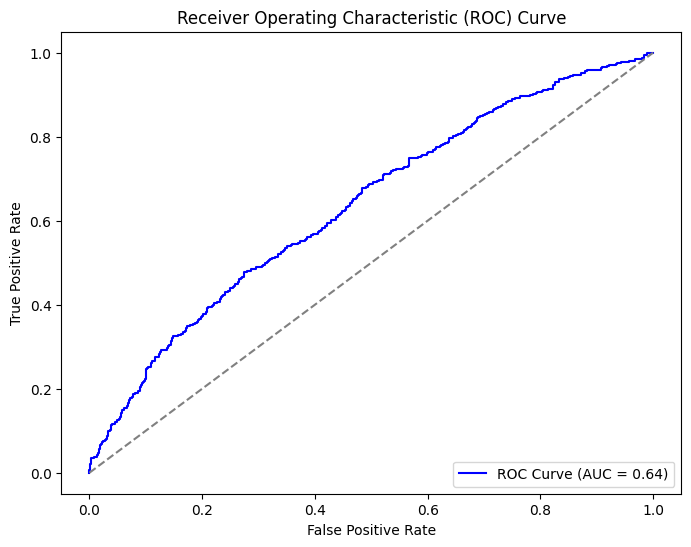

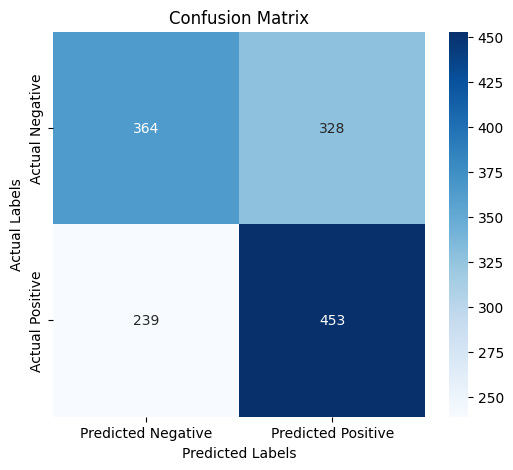

In [71]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (precision_score, recall_score, f1_score, roc_auc_score,
                             roc_curve, confusion_matrix, accuracy_score)
from sklearn.preprocessing import LabelBinarizer

# Assuming 'model' is your trained model and 'X_test', 'y_test' are your test data and labels

# 1. Obtain predicted probabilities for the positive class
y_probs = model.predict(ds_test).flatten() # Adjust indexing if your model has multiple outputs

# 2. Binarize the true labels if they are not already in binary forma

# 3. Compute evaluation metrics
y_pred = (y_probs > 0.5).astype(int)
precision = precision_score(y_test_bin, y_pred)
recall = recall_score(y_test_bin, y_pred)
f1 = f1_score(y_test_bin, y_pred)
roc_auc = roc_auc_score(y_test_bin, y_probs)
accuracy = accuracy_score(y_test_bin, y_pred)

# 4. Display the metrics
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1-Score: {f1:.4f}")
print(f"Test ROC AUC: {roc_auc:.4f}")

# 5. Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test_bin, y_probs)

# 6. Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

# 7. Compute confusion matrix
cm = confusion_matrix(y_test_bin, y_pred)

# 8. Plot confusion matrix using Seaborn heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('Confusion Matrix')
plt.show()


In [86]:
merged_df_new.columns

Index(['event_type', 'begin_date_time', 'cz_timezone', 'end_date_time',
       'begin_lat', 'begin_lon', 'end_lat', 'end_lon', 'extreme',
       'begin_date_utc', 'begin_time_utc', 'end_date_utc', 'end_time_utc',
       'cluster', 'start_date_72h', 'end_date', 'event_datetime',
       'prev_72h_weather', 'event_id', 'filenames', 'prev_72h_temperature_2m',
       'prev_72h_relative_humidity_2m', 'prev_72h_dew_point_2m',
       'prev_72h_apparent_temperature', 'prev_72h_precipitation',
       'prev_72h_rain', 'prev_72h_snowfall', 'prev_72h_snow_depth',
       'prev_72h_weather_code', 'prev_72h_pressure_msl',
       'prev_72h_surface_pressure', 'prev_72h_cloud_cover',
       'prev_72h_cloud_cover_low', 'prev_72h_cloud_cover_mid',
       'prev_72h_cloud_cover_high', 'prev_72h_et0_fao_evapotranspiration',
       'prev_72h_vapour_pressure_deficit', 'prev_72h_wind_speed_10m',
       'prev_72h_wind_speed_100m', 'prev_72h_wind_direction_10m',
       'prev_72h_wind_direction_100m', 'prev_72h_win

In [88]:
import datetime
def preprocess_datetime(datetime_str):
    """
    Convert a datetime string (format: "YYYY-MM-DD HH:MM:SS") into cyclic features.
    Extracts the hour and month, converting each to a sine and cosine value.
    Returns a list: [sin_hour, cos_hour, sin_month, cos_month]
    """
    dt = datetime.datetime.strptime(datetime_str, "%Y-%m-%d %H:%M:%S")
    hour = dt.hour
    month = dt.month
    # Cyclical transformation for hour (range [0, 24))
    hour_rad = 2 * np.pi * hour / 24.0
    sin_hour = np.sin(hour_rad)
    cos_hour = np.cos(hour_rad)
    # Cyclical transformation for month (range [1, 12], subtract 1 to shift to 0-11)
    month_rad = 2 * np.pi * (month - 1) / 12.0
    sin_month = np.sin(month_rad)
    cos_month = np.cos(month_rad)
    return [sin_hour, cos_hour, sin_month, cos_month]

def normalize_location(lat, lon, lat_bounds=(20, 50), lon_bounds=(-130, -60)):
    """
    Normalize latitude and longitude using min–max scaling given geographic bounds.
    Adjust the bounds as needed for your dataset.
    """
    lat_norm = (lat - lat_bounds[0]) / (lat_bounds[1] - lat_bounds[0])
    lon_norm = (lon - lon_bounds[0]) / (lon_bounds[1] - lon_bounds[0])
    return [lat_norm, lon_norm]

def create_meta_features(datetime_str, lat, lon):
    """
    Create combined meta features from raw datetime, latitude, and longitude.
    Returns an array of 6 features: 4 from datetime cyclic encoding and 2 normalized location values.
    """
    dt_features = preprocess_datetime(datetime_str)
    loc_features = normalize_location(lat, lon)
    return np.array(dt_features + loc_features)


In [89]:
# Create a wrapper function that works on a single row
def apply_meta_features(row):
    """Apply create_meta_features to a single DataFrame row"""
    return create_meta_features(
        datetime_str=row['begin_date_time'],
        lat=row['begin_lat'],
        lon=row['begin_lon']
    )

# Apply the function to each row
meta_features_series = merged_df_new.apply(apply_meta_features, axis=1)

# To create a DataFrame with proper columns
meta_features = pd.DataFrame(
    meta_features_series.tolist(),
    index=merged_df_new.index,
    columns=['sin_hour', 'cos_hour', 'sin_month', 'cos_month', 'lat_norm', 'lon_norm']
)

# If you want to add these features back to the original DataFrame
merged_df_new = pd.concat([merged_df_new, meta_features], axis=1)

In [92]:
merged_df_new["sin_hour"]

0      -8.660254e-01
1       1.224647e-16
2       7.071068e-01
3      -9.659258e-01
4      -1.000000e+00
            ...     
6913    2.588190e-01
6914    2.588190e-01
6915   -8.660254e-01
6916   -2.588190e-01
6917   -8.660254e-01
Name: sin_hour, Length: 6918, dtype: float64

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv1D, MaxPooling1D, Dropout,
                                     LSTM, Dense, Input)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.metrics import Precision, Recall, AUC
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential, Model # Import Model for Functional API
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, BatchNormalization, Activation,
    LSTM, Bidirectional, Dropout, Dense, LeakyReLU
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
# Import relevant metrics for classification, especially if data is imbalanced
from tensorflow.keras.metrics import Precision, Recall, AUC
# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# --- Data Preparation ---
# Assume merged_df and meteo_cols are defined earlier in your code.
# For multi-class, we now use the "event_type" column.

# Encode the categorical labels to integer values
le = LabelEncoder()
y_encoded = le.fit_transform(merged_df_new["event_type"].values)
# Number of classes (should be 10 based on provided counts)
num_classes = len(le.classes_)

# Convert integer labels to one-hot encoded format
y = tf.keras.utils.to_categorical(y_encoded, num_classes=num_classes)
y_bin = merged_df_new["extreme"].values # Binary labels for extreme events
# Prepare features (assuming meteo_cols contains your meteorological data)
# Here we simulate stacking the data; adjust if your actual data preprocessing is different.


# Split the data into training and testing sets
X_train, X_test, y_train, y_test, y_train_bin, y_test_bin = train_test_split(
    merged_df_new, y,y_bin, test_size=0.2, random_state=42, stratify=y_bin
)


X_train, X_validation, y_train_bin, y_validation_bin = train_test_split(
    X_train,y_train_bin, test_size=0.2, random_state=42, stratify=y_train_bin
)
from collections import Counter
from sklearn.datasets import make_classification
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
# Apply the oversampling to the dataset

X_train_metadata = X_train[["begin_date_time", "begin_lat", "begin_lon"]].copy()
X_test_metadata = X_test[["begin_date_time", "begin_lat", "begin_lon"]].copy()
X_validation_metadata = X_validation[["begin_date_time", "begin_lat", "begin_lon"]].copy()

X_images = X_train["images_loaded"].values
X_test_images = X_test["images_loaded"].values
X_validation_images = X_validation["images_loaded"].values


X_train = np.stack(X_train[meteo_cols].values.tolist(), axis=0)
X_test = np.stack(X_test[meteo_cols].values.tolist(), axis=0)
X_validation = np.stack(X_validation[meteo_cols].values.tolist(), axis=0)
# Initialize the RandomOverSampler

print("peecentage of positice instance in training data: ", sum(y_train_bin)/len(y_train_bin))
print("percentage of positice instance in test data: ", sum(y_test_bin)/len(y_test_bin))
print("percentage of positice instance in validation data: ", sum(y_validation_bin)/len(y_validation_bin))

print("y resampled shape:", y_train_bin.shape)
# Display class distribution after oversampling
print("Class distribution after oversampling:", Counter(y_train_bin))
# Scale the y_train_bin
scaler = StandardScaler()

# Reshape for scaling: combine timesteps and features
X_train = X_train.reshape(-1, X_train.shape[-1])
X_test = X_test.reshape(-1, X_test.shape[-1])
X_validation = X_validation.reshape(-1, X_validation.shape[-1])
# Fit and transform
print("X resampled shape before scaling:", X_train.shape)
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_validation = scaler.transform(X_validation)
# Reshape back to original structure: (samples, num_features, num_timesteps)
# Note: Here we assume the original shape was (samples, num_features, num_timesteps).
# Adjust reshaping if your data dimensions differ.
X_train = X_train.reshape(-1, 27, 72)
X_test = X_test.reshape(-1, 27, 72)
X_validation = X_validation.reshape(-1, 27, 72)
# Print shapes to verify correctness (should print something like (samples, 27, 72) and (samples, num_classes))
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train_bin.shape)

# --- Reshape Input for Model ---
# Rearranging shape to (samples, timesteps, features), here timesteps=72 and features=27.
X_train = X_train.transpose(0, 2, 1)
X_test  = X_test.transpose(0, 2, 1)
X_validation = X_validation.transpose(0, 2, 1)
num_timesteps = X_train.shape[1]  # should be 72
num_features  = X_train.shape[2]  # should be 27
input_layer = Input(shape=(num_timesteps, num_features))
# --- CNN Feature Extraction Block ---
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, LeakyReLU, MaxPooling1D, Dropout, Add, Dense, Bidirectional, LSTM, GlobalAveragePooling1D, Attention
from tensorflow.keras.optimizers import Adam






import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, LeakyReLU, MaxPooling1D, Dropout, Add, Bidirectional, LSTM, Attention, GlobalAveragePooling1D, Dense, concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

import tensorflow as tf
from tensorflow.keras.layers import (Input, Conv1D, Conv2D, BatchNormalization, LeakyReLU, 
                                     MaxPooling1D, MaxPooling2D, Dropout, Add, Bidirectional, 
                                     LSTM, Attention, GlobalAveragePooling1D, GlobalAveragePooling2D, 
                                     Dense, concatenate)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import (Input, Conv1D, BatchNormalization, LeakyReLU, MaxPooling1D, Dropout, Add, 
                                     Bidirectional, LSTM, Attention, GlobalAveragePooling1D, concatenate, 
                                     Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, TimeDistributed, Lambda)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import datetime

# ---------------------------
# Utility Functions for Preprocessing
# ---------------------------




# ---------------------------
# Model Definition
# ---------------------------

# Weather Data Branch
weather_input = Input(shape=(72, 27), name='weather_input')
w = Conv1D(filters=64, kernel_size=3, padding='same')(weather_input)
w = BatchNormalization()(w)
w = LeakyReLU(alpha=0.01)(w)
w = MaxPooling1D(pool_size=2)(w)
w = Dropout(0.3)(w)
w = Conv1D(filters=128, kernel_size=5, padding='same')(w)
w = BatchNormalization()(w)
w = LeakyReLU(alpha=0.01)(w)
w = Dropout(0.3)(w)
# Residual connection: slice first half of the input, then process it
shortcut = Lambda(lambda x: x[:, :tf.shape(x)[1] // 2, :])(weather_input)
shortcut = Conv1D(filters=128, kernel_size=1, padding='same')(shortcut)
shortcut = BatchNormalization()(shortcut)
w = Add()([w, shortcut])
w = Conv1D(filters=128, kernel_size=7, padding='same')(w)
w = BatchNormalization()(w)
w = LeakyReLU(alpha=0.01)(w)
w = Dropout(0.3)(w)
w = Bidirectional(LSTM(128, return_sequences=True))(w)
w = Dropout(0.4)(w)
w = Bidirectional(LSTM(64, return_sequences=True))(w)
w = Dropout(0.4)(w)
w = Attention()([w, w])
weather_features = GlobalAveragePooling1D()(w)

# Image Data Branch
image_input = Input(shape=(3, 64, 64, 3), name='image_input')
i = TimeDistributed(Conv2D(32, kernel_size=(3, 3), padding='same'))(image_input)
i = TimeDistributed(BatchNormalization())(i)
i = TimeDistributed(LeakyReLU(alpha=0.01))(i)
i = TimeDistributed(MaxPooling2D(pool_size=(2, 2)))(i)
i = TimeDistributed(Dropout(0.3))(i)
i = TimeDistributed(Conv2D(64, kernel_size=(3, 3), padding='same'))(i)
i = TimeDistributed(BatchNormalization())(i)
i = TimeDistributed(LeakyReLU(alpha=0.01))(i)
i = TimeDistributed(MaxPooling2D(pool_size=(2, 2)))(i)
i = TimeDistributed(Dropout(0.3))(i)
i = TimeDistributed(Conv2D(128, kernel_size=(3, 3), padding='same'))(i)
i = TimeDistributed(BatchNormalization())(i)
i = TimeDistributed(LeakyReLU(alpha=0.01))(i)
i = TimeDistributed(MaxPooling2D(pool_size=(2, 2)))(i)
i = TimeDistributed(Dropout(0.3))(i)
i = TimeDistributed(GlobalAveragePooling2D())(i)
i = Bidirectional(LSTM(128, return_sequences=True))(i)
i = Dropout(0.4)(i)
i = Bidirectional(LSTM(64, return_sequences=False))(i)
i = Dropout(0.4)(i)
img_features = Dense(128, activation='relu')(i)
img_features = BatchNormalization()(img_features)
img_features = Dropout(0.4)(img_features)

# Meta Data Branch (for datetime and location features)
# Here, we have a 6-dimensional input: [sin_hour, cos_hour, sin_month, cos_month, norm_lat, norm_lon]
meta_input = Input(shape=(6,), name='meta_input')
meta_features = Dense(16, activation='relu')(meta_input)
meta_features = BatchNormalization()(meta_features)
meta_features = Dropout(0.3)(meta_features)
meta_features = Dense(8, activation='relu')(meta_features)
meta_features = BatchNormalization()(meta_features)
meta_features = Dropout(0.3)(meta_features)

# Merge all branches
combined_features = concatenate([weather_features, img_features, meta_features], name='combined_features')
x = Dense(64, activation='relu')(combined_features)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
extreme_output = Dense(1, activation='sigmoid', name='extreme')(x)

model = Model(inputs=[weather_input, image_input, meta_input], outputs=extreme_output)
optimizer = Adam(learning_rate=1e-4, clipnorm=1.0)
model.compile(optimizer=optimizer,
              loss='binary_crossentropy',
              metrics=[tf.keras.metrics.Accuracy(name='accuracy'),
                       tf.keras.metrics.Precision(),
                       tf.keras.metrics.Recall(),
                       tf.keras.metrics.AUC(name='roc_auc'),
                       tf.keras.metrics.AUC(curve='PR', name='pr_auc')])

# Display the model summary
model.summary()

# --- Callbacks ---
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)


# --- Train the Model ---
epochs = 50
batch_size = 32




